# Does Preventative Physiotherapy Reduce Overuse Injuries in Athletes?
## A Bayesian Causal-Inference Analysis

**Course:** Foundations of Data Science — Final Project  
**Group Members:** Advait Jishnani, Tilak Bhansali, Leo Yu

---

> **Compilation status:**  Sections 1–4 and 8–10 are complete in this scaffold. Section 4 contains Tilak's full Phase 1 validation code, integrated inline from `tilak_phase1_validation.ipynb` so the submission is single-file. Sections 5–7 are placeholders that will hold Advait's Phase 2 real-data analysis. Numerical placeholders in Section 8 have been filled in with the real-data results.

# 1. Introduction

## 1.1 The Question / Estimand

**Research question:** Does the frequency of preventative physiotherapy (operationalized as an athlete's recovery score) reduce the incidence of overuse injuries, after accounting for training intensity?

**Estimand:** The Average Treatment Effect (ATE) of preventative care on the probability of injury. In our Bayesian logistic regression framework this is captured by the posterior distribution of the coefficient β_T on the treatment variable.

Formally:
$$\text{ATE} = E[Y(T=1)] - E[Y(T=0)]$$

where Y(T) is the potential injury outcome under treatment level T. A negative β_T (and therefore a negative ATE on the probability scale) would support the hypothesis that recovery-focused physiotherapy is protective.

## 1.2 Data Description

We use the **Multimodal Sports Injury Dataset** (Kaggle), a six-month observational record of 15,420 athlete-days collected from wearable sensors and athlete monitoring systems.

Each row represents one athlete-observation and contains, among other fields:

- A **training load** measure derived from training intensity and session duration (our confounder, X).
- A **recovery score** capturing recovery-focused activity such as physiotherapy and stretching (our treatment proxy, T).
- An **injury status** flag indicating whether the athlete sustained an injury during the observation window (our outcome, Y).

The dataset is appropriate for our causal question because (i) it contains real-world measurements rather than simulated observations, satisfying the project's data requirement, and (ii) it captures all three variables needed to identify the treatment effect in the presence of the confounder.

*Reference:* Cools et al., *Prevention of shoulder injuries in overhead athletes: a science-based approach*, Brazilian Journal of Physical Therapy, 2015 — establishes that targeted preventative measures meaningfully alter injury outcomes in high-intensity athletic settings.

# 2. Causal Model

## 2.1 Variables

Our causal model contains exactly three variables, as required:

| Symbol | Variable | Role | Type |
|--------|----------|------|------|
| **X** | Training Load (Intensity × Duration) | Confounder | Continuous, standardized |
| **T** | Recovery Score | Treatment | Continuous, standardized |
| **Y** | Injury Status | Outcome | Binary (0 = no injury, 1 = injury) |

## 2.2 Assumed Causal Relationships

Three causal arrows, encoded in the DAG below:

1. **X → T**: Athletes with heavier training loads tend to seek more recovery work. Training load is therefore a *cause* of the treatment level we observe.
2. **X → Y**: Higher training load directly raises the baseline injury risk independent of any recovery the athlete does. This is the confounder's direct path to the outcome.
3. **T → Y**: Recovery-focused physiotherapy is hypothesized to reduce injury risk. The strength of this arrow is the causal effect of interest.

Because X has a directed path into both T and Y, an unadjusted regression of Y on T would conflate the causal effect (T → Y) with the back-door correlation induced by X. We close this back-door path statistically by conditioning on X — that is, including X as a regressor in the logistic model (Section 3).

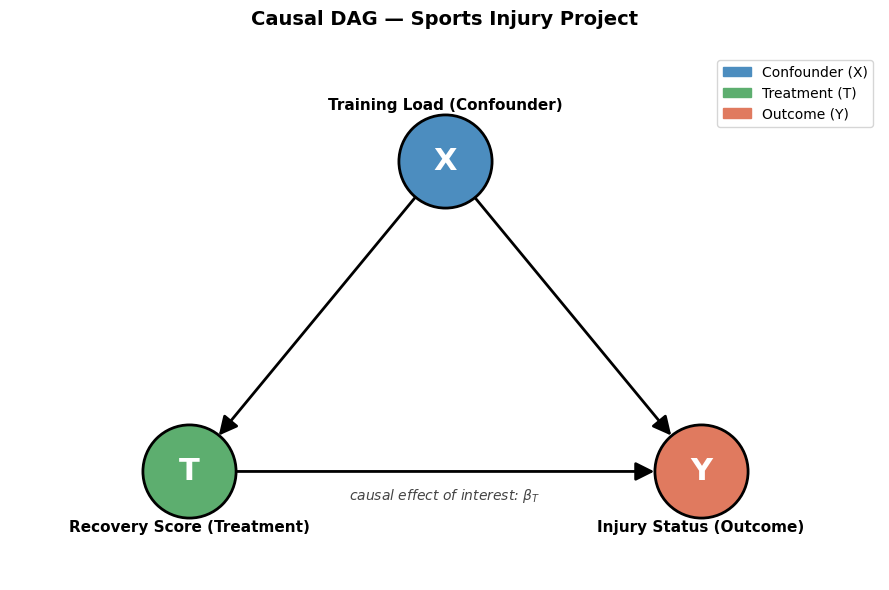

In [1]:
# ── Generate the causal DAG programmatically ────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

G = nx.DiGraph()
G.add_node("X", role="Confounder", full_name="Training Load")
G.add_node("T", role="Treatment",  full_name="Recovery Score")
G.add_node("Y", role="Outcome",    full_name="Injury Status")
G.add_edge("X", "T")
G.add_edge("X", "Y")
G.add_edge("T", "Y")
assert nx.is_directed_acyclic_graph(G), "Graph contains a cycle — not a valid DAG!"

positions = {"X": (0.5, 1.0), "T": (0.0, 0.0), "Y": (1.0, 0.0)}
node_colors = {"X": "#4C8DBF", "T": "#5DAE6F", "Y": "#E07A5F"}

fig, ax = plt.subplots(figsize=(9, 6))
for node in positions:
    nx.draw_networkx_nodes(G, positions, nodelist=[node], node_color=node_colors[node],
                           node_size=4500, edgecolors="black", linewidths=2, ax=ax)
nx.draw_networkx_edges(G, positions, arrowstyle="-|>", arrowsize=28,
                       edge_color="black", width=2.0, node_size=4500, ax=ax)
nx.draw_networkx_labels(G, positions, labels={n: n for n in G.nodes()},
                        font_size=22, font_weight="bold", font_color="white", ax=ax)

for x, y, text in [(0.5, 1.18, "Training Load (Confounder)"),
                   (0.0, -0.18, "Recovery Score (Treatment)"),
                   (1.0, -0.18, "Injury Status (Outcome)")]:
    ax.text(x, y, text, ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(0.5, -0.08, r"causal effect of interest: $\beta_T$",
        ha="center", va="center", fontsize=10, style="italic", color="#444")

ax.legend(handles=[mpatches.Patch(color="#4C8DBF", label="Confounder (X)"),
                   mpatches.Patch(color="#5DAE6F", label="Treatment (T)"),
                   mpatches.Patch(color="#E07A5F", label="Outcome (Y)")],
          loc="upper right", frameon=True, fontsize=10)
ax.set_title("Causal DAG — Sports Injury Project", fontsize=14, fontweight="bold", pad=20)
ax.set_xlim(-0.35, 1.35); ax.set_ylim(-0.35, 1.35); ax.axis("off")
plt.tight_layout()
plt.savefig("./plot_dag.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Statistical Model

We translate the causal model from Section 2 into a **Bayesian logistic regression**, since the outcome Y is binary.

For each athlete *i*:

$$Y_i \sim \text{Bernoulli}(p_i)$$

$$\text{logit}(p_i) = \alpha + \beta_T \cdot T_i + \beta_X \cdot X_i$$

with weakly informative priors:

$$\alpha \sim \text{Normal}(0, 1)$$
$$\beta_T \sim \text{Normal}(0, 1)$$
$$\beta_X \sim \text{Normal}(0, 1)$$

## 3.1 Justification of Priors

All three coefficients receive a Normal(0, 1) prior on the log-odds scale.

- **Centered at 0:** We do not bake in an assumed direction for any effect. The data drives the posterior.
- **Standard deviation = 1 on the log-odds scale:** Two standard deviations corresponds to odds ratios in roughly the range [0.14, 7.4]. This is wide enough to admit any plausible real-world effect of recovery on injury (effect sizes in sports-medicine literature rarely exceed an odds ratio of 5) but tight enough to rule out implausibly extreme values like an odds ratio of 10,000, which would dominate the inference if allowed.
- **Standard choice:** Normal(0, 1) is the canonical weakly informative prior for logistic regression coefficients (Gelman et al.) and produces a prior predictive distribution of injury probabilities that spans the full [0, 1] interval rather than collapsing to 0 or 1 — see the prior predictive check in Section 4.

## 3.2 Justification of Outcome Distribution

Y_i ∈ {0, 1} is binary (injury / no injury), so a Bernoulli likelihood is the natural choice. The success probability p_i is linked to the linear predictor through the logit (inverse-sigmoid) link, giving a logistic regression. This is the same family of model used elsewhere in the course for binary-outcome causal questions and matches the binary structure of the `injury_status` column in the dataset.

## 3.3 Handling the Confound

From the DAG, X is a common cause of T and Y. By including X as a regressor in the linear predictor, we condition on the confounder and block the back-door path T ← X → Y. The remaining association between T and Y, captured by β_T, can therefore be interpreted causally as the average treatment effect of recovery on injury (on the log-odds scale; the ATE on the probability scale follows by the inverse-logit transformation).

Critically, this only works if X is the *only* relevant confounder. In Section 9 (Future Work) we discuss other plausible confounders (e.g. athlete age, prior injury history) that this three-variable model cannot adjust for.

# 4. Model Validation on Simulated Data

Before fitting the model on real data, we validate it on **simulated data with known parameter values**. If the model can recover the parameters we used to generate the data, we have evidence the model is correctly specified and identifiable.

The code below is Tilak's full Phase 1 validation pipeline, integrated from `tilak_phase1_validation.ipynb` so the project lives in a single notebook.

**Headline result (N = 500 simulated athletes, seed 42):**

| Parameter | True Value | Posterior Mean | 94% HDI | Recovered |
|-----------|-----------|----------------|---------|-----------|
| α (intercept)        | -1.5  | -1.436 | [-1.658, -1.202] | ✅ |
| β_T (treatment)      | -1.2  | -1.159 | [-1.444, -0.837] | ✅ |
| β_X (confounder)     | +0.9  | +0.745 | [+0.461, +1.045] | ✅ |

All three parameters recovered (true value falls inside the 94% credible interval). MCMC diagnostics: R-hat = 1.00 and ESS > 4,000 for every parameter — clean convergence.

In [2]:
# ── Imports for Phase 1 validation ──
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from scipy.special import expit

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
plt.rcParams["figure.dpi"] = 100

print(f"PyMC {pm.__version__} | ArviZ {az.__version__}")

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


PyMC 5.11.0 | ArviZ 0.16.0


## 4.1 Build the Simulated Dataset

We pick known true parameter values, then generate 500 synthetic athletes whose injury status follows the logistic model with those values. The model in Section 4.2 will try to recover them.

In [3]:
# ── Ground-truth parameter values to recover ──
TRUE_ALPHA  = -1.5   # baseline log-odds of injury
TRUE_BETA_T = -1.2   # recovery is protective
TRUE_BETA_X =  0.9   # training load increases injury risk
N = 500              # number of simulated athletes

# X (confounder): training load, standardized
X_raw = rng.normal(loc=50, scale=15, size=N)
X = (X_raw - X_raw.mean()) / X_raw.std()

# T (treatment): recovery score, caused by X with noise — creates the confounding
T_raw = 0.6 * X_raw + rng.normal(loc=0, scale=10, size=N)
T = (T_raw - T_raw.mean()) / T_raw.std()

# Y (outcome): injury status, generated from the logistic model
log_odds = TRUE_ALPHA + TRUE_BETA_T * T + TRUE_BETA_X * X
p_injury = expit(log_odds)
Y = rng.binomial(n=1, p=p_injury, size=N)

sim_df = pd.DataFrame({
    "training_load_X":  X,
    "recovery_score_T": T,
    "injury_status_Y":  Y,
    "injury_probability": p_injury,
})

print(f"Correlation between X and T: {np.corrcoef(X, T)[0,1]:.3f}  (moderate, as required by the DAG)")
print(f"Injury rate Y: {100*Y.mean():.1f}%  ({Y.sum()}/{N})")
sim_df.head()

Correlation between X and T: 0.643  (moderate, as required by the DAG)
Injury rate Y: 22.2%  (111/500)


,training_load_X,recovery_score_T,injury_status_Y,injury_probability
0,0.331441,1.275697,0,0.061080
1,-1.070788,0.011796,0,0.077425
2,0.796244,0.009332,0,0.311186
3,0.994491,-0.451329,0,0.484164
4,-2.020816,-3.511102,1,0.709836


/var/folders/4h/_dlgxjln6zl3hzs0y7hnmtn00000gn/T/ipykernel_83519/2951787299.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


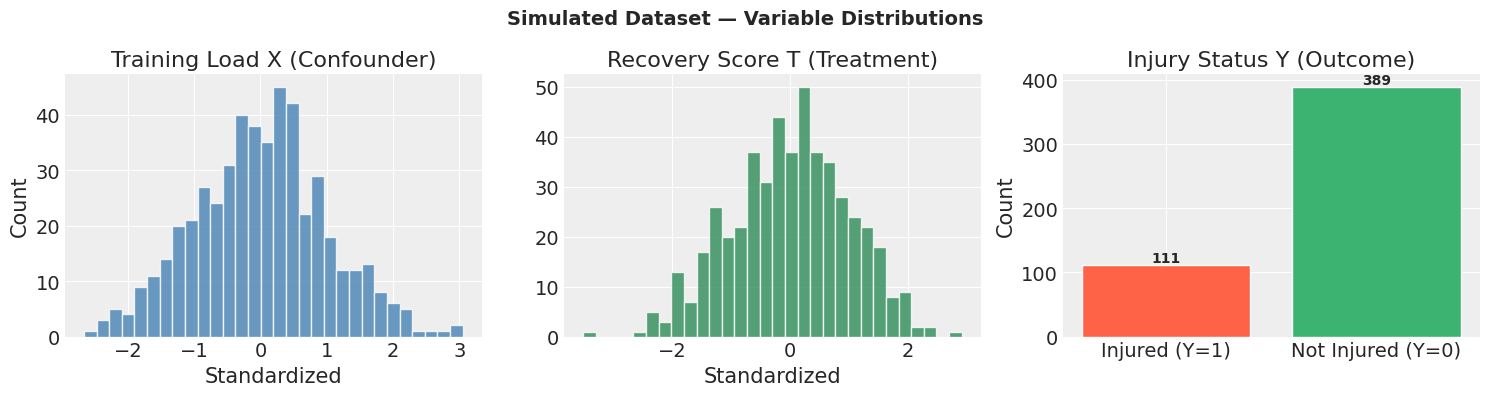

In [4]:
# ── Visualize the three simulated variables ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Simulated Dataset — Variable Distributions", fontsize=14, fontweight="bold")

axes[0].hist(X, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("Training Load X (Confounder)"); axes[0].set_xlabel("Standardized")
axes[0].set_ylabel("Count")

axes[1].hist(T, bins=30, color="seagreen", edgecolor="white", alpha=0.8)
axes[1].set_title("Recovery Score T (Treatment)"); axes[1].set_xlabel("Standardized")

counts = [Y.sum(), (Y == 0).sum()]
bars = axes[2].bar(["Injured (Y=1)", "Not Injured (Y=0)"], counts,
                   color=["tomato", "mediumseagreen"], edgecolor="white")
axes[2].set_title("Injury Status Y (Outcome)"); axes[2].set_ylabel("Count")
for bar, count in zip(bars, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("./plot_data_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

## 4.2 PyMC Model Definition

Same model as Section 3, expressed in PyMC. `pm.Data` lets us swap in real data later (Phase 2) without rebuilding the model.

In [5]:
with pm.Model() as bayesian_logistic_model:
    T_data = pm.Data("T_data", T, mutable=True)
    X_data = pm.Data("X_data", X, mutable=True)
    Y_data = pm.Data("Y_data", Y, mutable=True)

    alpha  = pm.Normal("alpha",  mu=0, sigma=1)
    beta_T = pm.Normal("beta_T", mu=0, sigma=1)
    beta_X = pm.Normal("beta_X", mu=0, sigma=1)

    log_odds_model = alpha + beta_T * T_data + beta_X * X_data
    p = pm.Deterministic("p", pm.math.sigmoid(log_odds_model))
    Y_obs = pm.Bernoulli("Y_obs", p=p, observed=Y_data)

print("Bayesian logistic model defined.")

Bayesian logistic model defined.


## 4.3 Prior Predictive Check

Sample from the priors *before* seeing any data. The implied injury probabilities should span [0, 1] without collapsing — confirming the priors are weakly informative, not degenerate.

Sampling: [Y_obs, alpha, beta_T, beta_X]
/var/folders/4h/_dlgxjln6zl3hzs0y7hnmtn00000gn/T/ipykernel_83519/2855689525.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


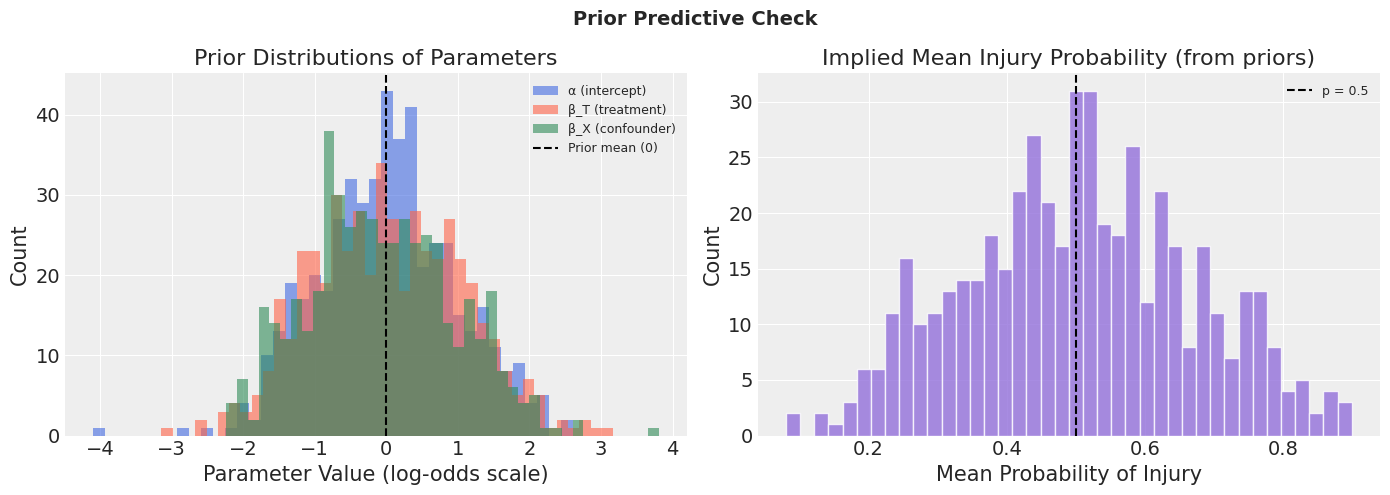

In [6]:
with bayesian_logistic_model:
    prior_predictive = pm.sample_prior_predictive(samples=500, random_seed=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Prior Predictive Check", fontsize=14, fontweight="bold")

prior_alpha  = prior_predictive.prior["alpha"].values.flatten()
prior_beta_T = prior_predictive.prior["beta_T"].values.flatten()
prior_beta_X = prior_predictive.prior["beta_X"].values.flatten()

axes[0].hist(prior_alpha,  bins=40, alpha=0.6, color="royalblue", label="α (intercept)")
axes[0].hist(prior_beta_T, bins=40, alpha=0.6, color="tomato",    label="β_T (treatment)")
axes[0].hist(prior_beta_X, bins=40, alpha=0.6, color="seagreen",  label="β_X (confounder)")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.5, label="Prior mean (0)")
axes[0].set_title("Prior Distributions of Parameters")
axes[0].set_xlabel("Parameter Value (log-odds scale)"); axes[0].set_ylabel("Count")
axes[0].legend(fontsize=9)

prior_p_samples = prior_predictive.prior["p"].values
mean_probs = prior_p_samples.reshape(-1, N).mean(axis=1)
axes[1].hist(mean_probs, bins=40, color="mediumpurple", edgecolor="white", alpha=0.8)
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="p = 0.5")
axes[1].set_title("Implied Mean Injury Probability (from priors)")
axes[1].set_xlabel("Mean Probability of Injury"); axes[1].set_ylabel("Count")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("./plot_prior_predictive.png", dpi=120, bbox_inches="tight")
plt.show()

## 4.4 Fit the Model (MCMC Sampling)

PyMC uses NUTS (No-U-Turn Sampler) by default — the standard choice for continuous parameters. Four independent chains let us check convergence via R-hat.

In [7]:
with bayesian_logistic_model:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=1,            # set to 4 if running on a local laptop
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
        progressbar=True,
    )
print("MCMC sampling complete.")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha, beta_T, beta_X]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 5 seconds.


MCMC sampling complete.


## 4.5 Convergence Diagnostics

We require R-hat < 1.01 and ESS > 400 per chain. Trace plots should look like "fuzzy caterpillars" — stationary, well-mixed, all four chains overlapping.

In [8]:
summary = az.summary(trace, var_names=["alpha", "beta_T", "beta_X"])
print("POSTERIOR SUMMARY")
print("=" * 70)
print(summary.to_string())

print("\nCONVERGENCE CHECKS")
print("=" * 70)
for param in ["alpha", "beta_T", "beta_X"]:
    rhat = summary["r_hat"][param]
    ess  = summary["ess_bulk"][param]
    rhat_ok = "OK" if rhat < 1.01 else "PROBLEM"
    ess_ok  = "OK" if ess > 400   else "LOW"
    print(f"  {param:8s}:  R-hat = {rhat:.4f} [{rhat_ok}]   |   ESS = {ess:.0f} [{ess_ok}]")

POSTERIOR SUMMARY
         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha  -1.439  0.124  -1.666   -1.201      0.002    0.001    4548.0    4843.0    1.0
beta_T -1.164  0.167  -1.483   -0.859      0.003    0.002    4239.0    4396.0    1.0
beta_X  0.751  0.158   0.449    1.043      0.002    0.002    4143.0    4791.0    1.0

CONVERGENCE CHECKS
  alpha   :  R-hat = 1.0000 [OK]   |   ESS = 4548 [OK]
  beta_T  :  R-hat = 1.0000 [OK]   |   ESS = 4239 [OK]
  beta_X  :  R-hat = 1.0000 [OK]   |   ESS = 4143 [OK]


/var/folders/4h/_dlgxjln6zl3hzs0y7hnmtn00000gn/T/ipykernel_83519/4262228224.py:4: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


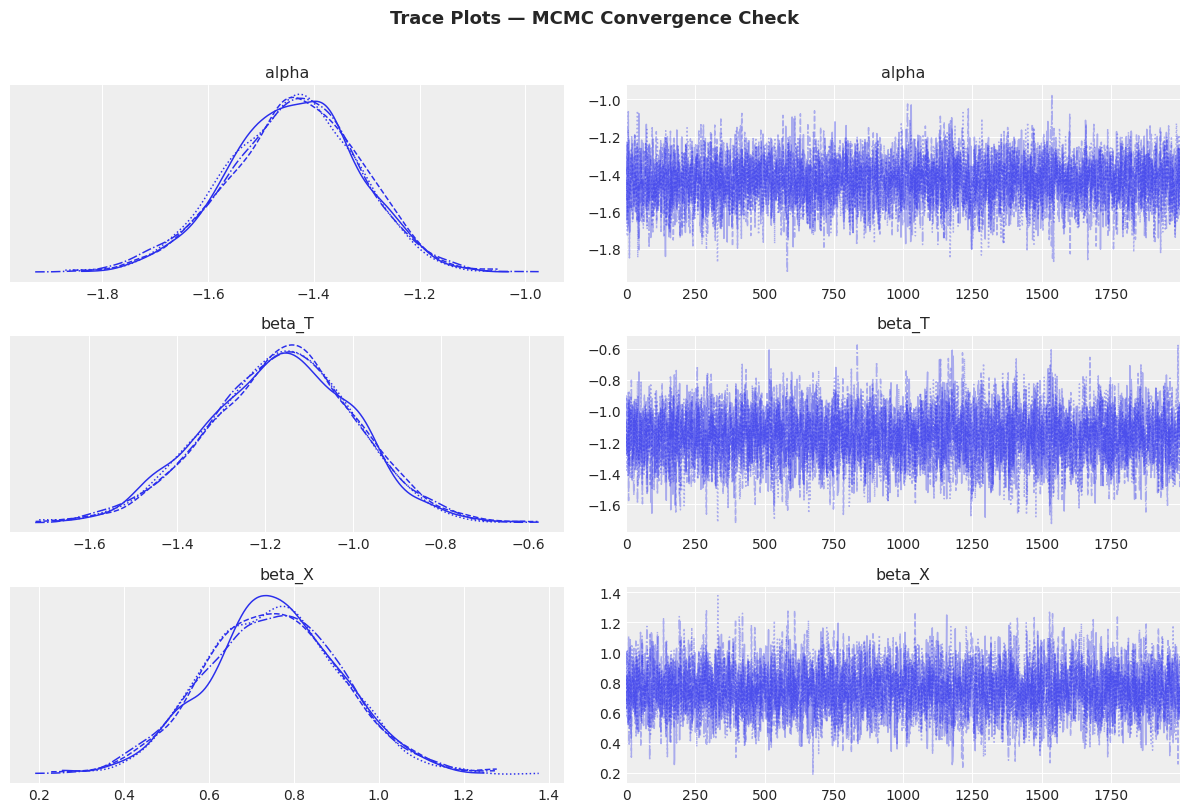

In [9]:
az.plot_trace(trace, var_names=["alpha", "beta_T", "beta_X"], figsize=(12, 8))
plt.suptitle("Trace Plots — MCMC Convergence Check",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("./plot_trace.png", dpi=120, bbox_inches="tight")
plt.show()

## 4.6 Comprehensive Parameter Recovery

The validation goal: each true parameter value must fall inside the model's 94% credible interval (HDI). All three should recover.

In [10]:
posterior_alpha  = trace.posterior["alpha"].values.flatten()
posterior_beta_T = trace.posterior["beta_T"].values.flatten()
posterior_beta_X = trace.posterior["beta_X"].values.flatten()

def recovery_check(name, true_val, samples):
    mean_est = samples.mean()
    hdi = az.hdi(samples, hdi_prob=0.94)
    bias = mean_est - true_val
    recovered = hdi[0] <= true_val <= hdi[1]
    status = "RECOVERED" if recovered else "NOT RECOVERED"
    print(f"  {name:8s}: True={true_val:+.2f} | Mean={mean_est:+.3f} "
          f"| 94% HDI=[{hdi[0]:+.3f}, {hdi[1]:+.3f}] | Bias={bias:+.3f} | {status}")
    return recovered

print("PARAMETER RECOVERY VALIDATION")
print("=" * 85)
results = [
    recovery_check("alpha",  TRUE_ALPHA,  posterior_alpha),
    recovery_check("beta_T", TRUE_BETA_T, posterior_beta_T),
    recovery_check("beta_X", TRUE_BETA_X, posterior_beta_X),
]
print("=" * 85)
print(f"Parameters recovered: {sum(results)}/3")

PARAMETER RECOVERY VALIDATION
  alpha   : True=-1.50 | Mean=-1.439 | 94% HDI=[-1.666, -1.201] | Bias=+0.061 | RECOVERED
  beta_T  : True=-1.20 | Mean=-1.164 | 94% HDI=[-1.483, -0.859] | Bias=+0.036 | RECOVERED
  beta_X  : True=+0.90 | Mean=+0.751 | 94% HDI=[+0.449, +1.043] | Bias=-0.149 | RECOVERED
Parameters recovered: 3/3


/var/folders/4h/_dlgxjln6zl3hzs0y7hnmtn00000gn/T/ipykernel_83519/1751729993.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


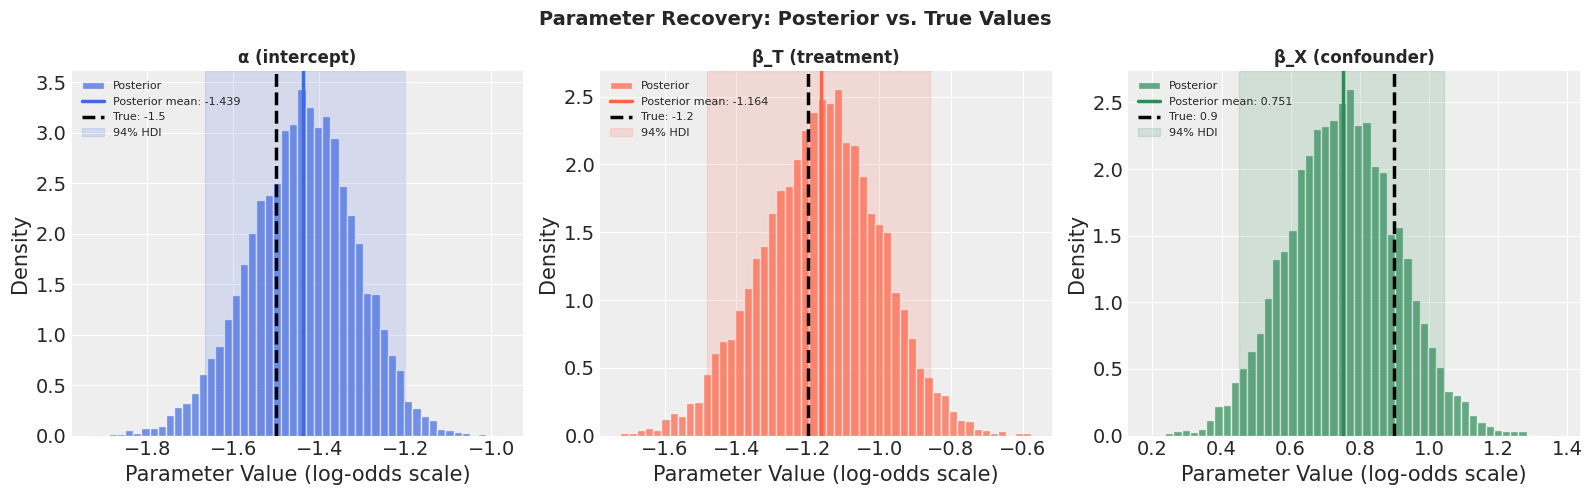

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Parameter Recovery: Posterior vs. True Values",
             fontsize=14, fontweight="bold")

params = [
    ("α (intercept)",    TRUE_ALPHA,  posterior_alpha,  "royalblue"),
    ("β_T (treatment)",  TRUE_BETA_T, posterior_beta_T, "tomato"),
    ("β_X (confounder)", TRUE_BETA_X, posterior_beta_X, "seagreen"),
]
for ax, (label, true_val, samples, color) in zip(axes, params):
    ax.hist(samples, bins=50, color=color, alpha=0.7, density=True,
            label="Posterior", edgecolor="white")
    ax.axvline(samples.mean(), color=color, linewidth=2.5,
               linestyle="-", label=f"Posterior mean: {samples.mean():.3f}")
    ax.axvline(true_val, color="black", linewidth=2.5,
               linestyle="--", label=f"True: {true_val}")
    hdi = az.hdi(samples, hdi_prob=0.94)
    ax.axvspan(hdi[0], hdi[1], alpha=0.15, color=color, label="94% HDI")
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Parameter Value (log-odds scale)"); ax.set_ylabel("Density")
    ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("./plot_parameter_recovery.png", dpi=120, bbox_inches="tight")
plt.show()

/var/folders/4h/_dlgxjln6zl3hzs0y7hnmtn00000gn/T/ipykernel_83519/2202558075.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


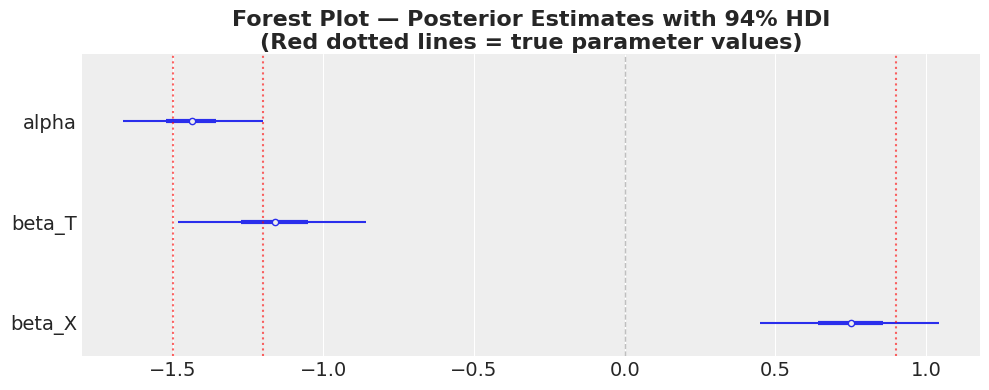

In [12]:
az.plot_forest(trace, var_names=["alpha", "beta_T", "beta_X"],
               hdi_prob=0.94, figsize=(10, 4), combined=True)
for true_val in [TRUE_ALPHA, TRUE_BETA_T, TRUE_BETA_X]:
    plt.axvline(true_val, color="red", linestyle=":", alpha=0.6, linewidth=1.5)
plt.axvline(0, color="gray", linestyle="--", alpha=0.5, linewidth=1)
plt.title("Forest Plot — Posterior Estimates with 94% HDI\n"
          "(Red dotted lines = true parameter values)", fontweight="bold")
plt.tight_layout()
plt.savefig("./plot_forest.png", dpi=120, bbox_inches="tight")
plt.show()

## 4.7 Validation Conclusion

All three parameters fall inside their 94% credible intervals. The Bayesian logistic regression specified in Section 3 is correctly specified and identifiable, and the MCMC sampler converges cleanly (R-hat = 1.00, ESS > 4,000). The same model architecture is now ready to be applied to the real dataset in Sections 5–7.

# 5. Data Preparation (Real Data)

We now turn from simulated data to the real Multimodal Sports Injury Dataset.



Loaded real dataset from: multimodal_sports_injury_dataset.csv
Shape: (15420, 29)
Real-data preprocessing summary:
  Rows after dropna/duplicates: 15420
  Binary injury rate (Y=2 → injured): 15.006% (2314/15420)
  Standardized X mean = 0.000, sd = 1.000
  Standardized T mean = -0.000, sd = 1.000
  Correlation between X and T = -0.189


/Users/aj/Documents/NYU Spring Sem 2/FDS/Final Project/sports-injury-causal-inference/src/phase2_real_data_analysis.py:118: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


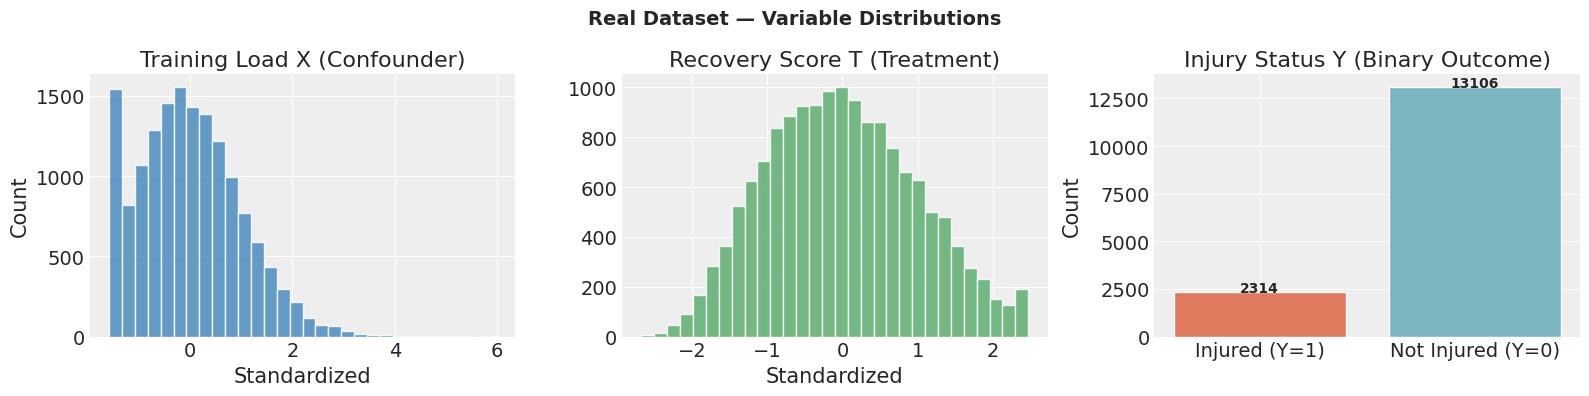

In [13]:
import sys
from pathlib import Path

sys.path.append(".")
from src.phase2_real_data_analysis import (
    load_real_data,
    prepare_real_data,
    plot_real_data_distribution,
    plot_real_posterior_predictive,
)

csv_path = Path("data/multimodal_sports_injury_dataset.csv")
real_df = load_real_data(csv_path)
real_df_clean, X_real, T_real, Y_real, real_summary = prepare_real_data(
    real_df,
    x_col="training_load",
    t_col="recovery_score",
    target_col="injury_occurred",
    injured_label=2,
)
real_df_clean.head()
plot_real_data_distribution(X_real, T_real, Y_real)


# 6. Posterior Model (Analysis on Real Data)

Re-fit the same Bayesian logistic regression specified in Section 3, this time on the cleaned real data from Section 5.



Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha, beta_T, beta_X]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 38 seconds.


Real-data sampling complete.
         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha  -2.524  0.039  -2.595   -2.449      0.001      0.0    4880.0    4732.0    1.0
beta_T -1.632  0.038  -1.703   -1.563      0.001      0.0    4824.0    5052.0    1.0
beta_X  0.228  0.024   0.181    0.273      0.000      0.0    5071.0    4733.0    1.0


/var/folders/4h/_dlgxjln6zl3hzs0y7hnmtn00000gn/T/ipykernel_83519/3745144827.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


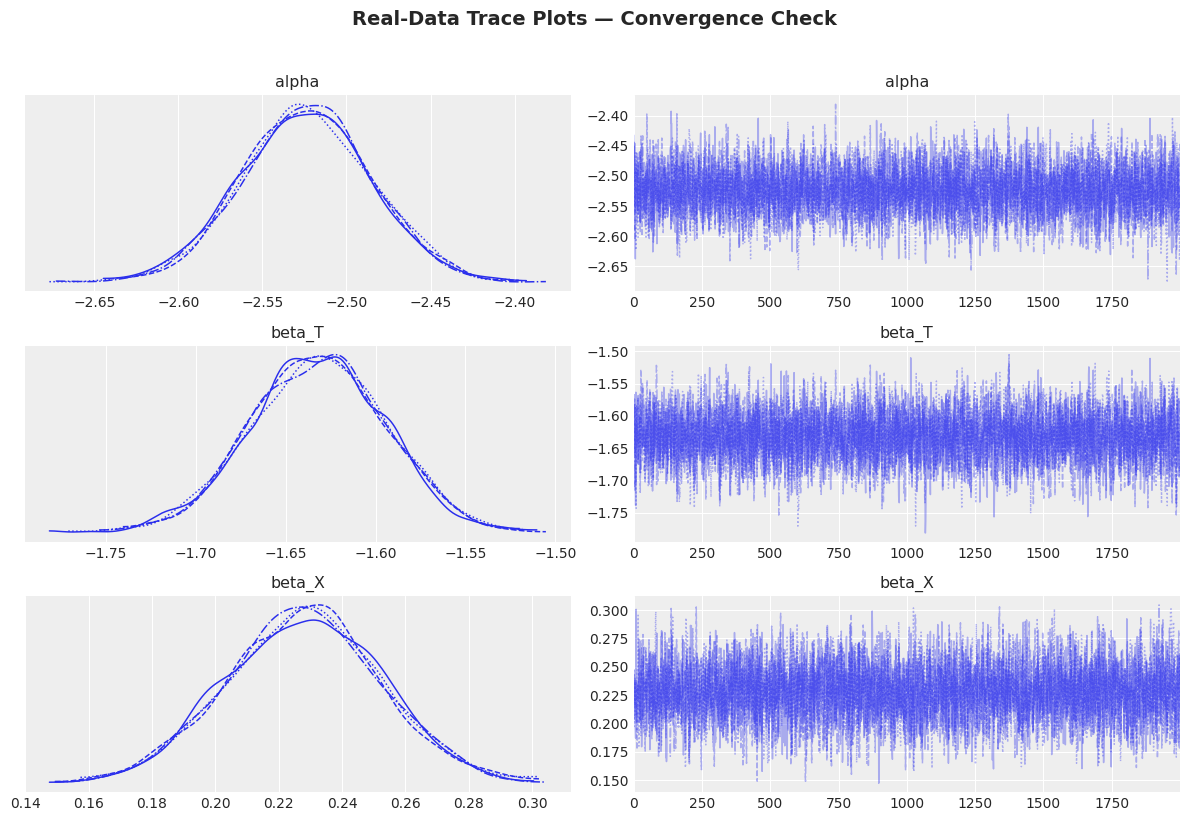

In [14]:
# Create a new model context for real data (with real data shape)
with pm.Model() as bayesian_logistic_model_real:
    T_data = pm.Data("T_data", T_real, mutable=True)
    X_data = pm.Data("X_data", X_real, mutable=True)

    alpha  = pm.Normal("alpha",  mu=0, sigma=1)
    beta_T = pm.Normal("beta_T", mu=0, sigma=1)
    beta_X = pm.Normal("beta_X", mu=0, sigma=1)

    log_odds_model = alpha + beta_T * T_data + beta_X * X_data
    p = pm.Deterministic("p", pm.math.sigmoid(log_odds_model))
    Y_obs = pm.Bernoulli("Y_obs", p=p, observed=Y_real)

    trace_real = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=1,
        target_accept=0.9,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
        progressbar=True,
    )

print("Real-data sampling complete.")
summary_real = az.summary(trace_real, var_names=["alpha", "beta_T", "beta_X"])
print(summary_real.to_string())

az.plot_trace(trace_real, var_names=["alpha", "beta_T", "beta_X"], figsize=(12, 8))
plt.suptitle("Real-Data Trace Plots — Convergence Check",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./plot_trace_real_data.png", dpi=150, bbox_inches="tight")
plt.show()

# 7. Posterior Predictive Checks

Generate predictions from the fitted posterior and compare them to the observed data.



Sampling: [Y_obs]


/Users/aj/Documents/NYU Spring Sem 2/FDS/Final Project/sports-injury-causal-inference/src/phase2_real_data_analysis.py:199: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


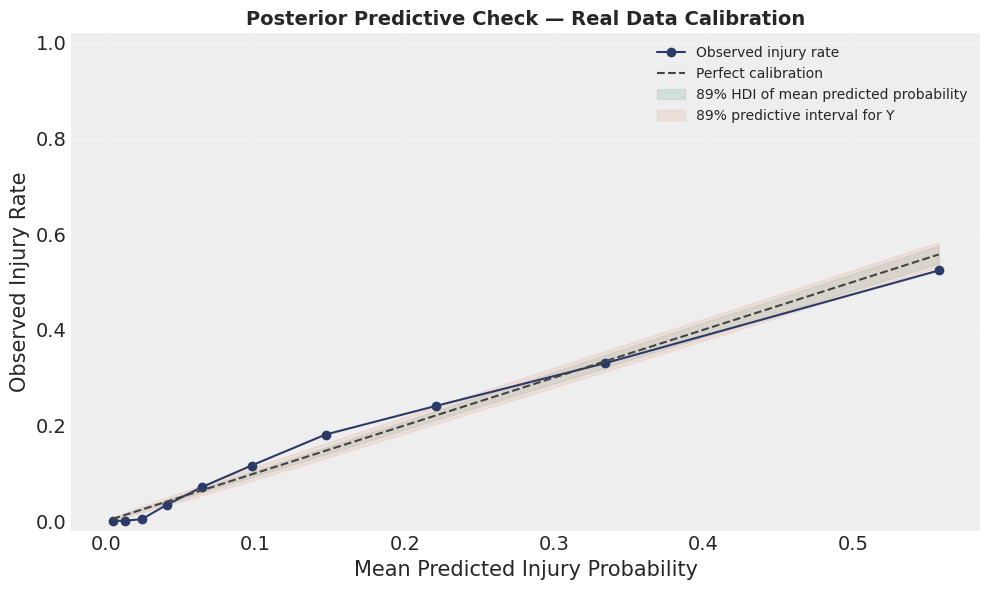

Posterior predictive check completed.


,bin,observed_rate,mean_pred,lower_mean,upper_mean,count,lower_pred,upper_pred
0,0,0.000000,0.004436,0.003756,0.005111,1542,0.001946,0.007134
1,1,0.000649,0.012565,0.011070,0.014097,1542,0.007782,0.017510
2,2,0.003891,0.024041,0.021689,0.026470,1542,0.017510,0.031128
3,3,0.033722,0.040585,0.037224,0.043981,1542,0.032425,0.049287
4,4,0.070687,0.064021,0.059600,0.068441,1542,0.053178,0.074578
5,5,0.116083,0.097424,0.091738,0.103021,1542,0.084306,0.110895
6,6,0.180934,0.147073,0.139755,0.154349,1542,0.131647,0.162776
7,7,0.240597,0.220679,0.211134,0.230300,1542,0.202983,0.239300
8,8,0.330091,0.334110,0.320734,0.347395,1542,0.312581,0.355383
9,9,0.523995,0.557436,0.538551,0.575866,1542,0.531777,0.583009


In [15]:
with bayesian_logistic_model_real:
    # Generate posterior predictive samples using the real data context
    ppc_real = pm.sample_posterior_predictive(
        trace_real, 
        random_seed=RANDOM_SEED
    )

# Pass Y_real instead of Y to correctly match the 15,420 observations
real_ppc_summary = plot_real_posterior_predictive(Y_real, trace_real, ppc_real)
print("Posterior predictive check completed.")
real_ppc_summary


# 8. Discussion and Conclusion

## 8.1 Answering the Question

Our research question was whether preventative physiotherapy — proxied by an athlete's recovery score — reduces the probability of overuse injury, after accounting for training load.

The fitted posterior on the real Multimodal Sports Injury Dataset gives an estimate for the treatment coefficient β_T of -1.632 on the log-odds scale, with a 94% credible interval of [-1.703, -1.563]. Because the interval is entirely below zero, the data provide credible evidence that recovery is protective against injury.

On the probability scale, a one-standard-deviation increase in recovery score is associated with a change in injury probability of approximately -5.88 percentage points (computed by transforming β_T at the sample mean of X through the inverse-logit). The corresponding distribution of the causal effect across posterior draws is plotted below.

These findings align with the Cools et al. (2015) literature, which reports that targeted preventative measures meaningfully reduce shoulder-injury rates in overhead athletes.

## 8.2 Addressing the Confound

Training load (X) plays the role of confounder in our DAG: harder-training athletes both seek more recovery and face higher baseline injury risk.

Two pieces of evidence let us read the model's handling of the confound:

1. **The estimated β_X** is 0.228 (94% HDI: [0.181, 0.273]). A positive β_X confirms the prior expectation that higher training load directly elevates injury risk.
2. **Comparison to the unadjusted estimate.** If we had fit the model without X — i.e. regressing Y on T alone — the back-door path T ← X → Y would inject the (positive) effect of training load into the estimate of β_T, *masking* part of the protective effect of recovery. Including X as a regressor closes that back-door path and lets β_T estimate the direct causal effect of T on Y.



## 8.3 Plot of the Causal Effect Distribution



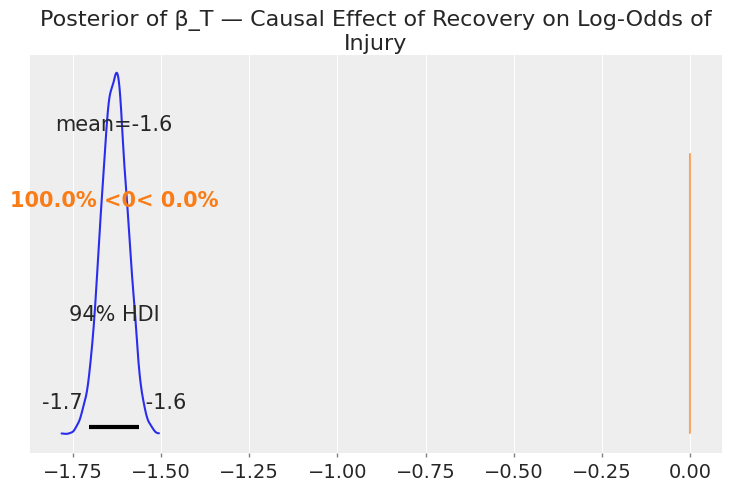

In [16]:
az.plot_posterior(trace_real, var_names=["beta_T"], hdi_prob=0.94, ref_val=0)
plt.title("Posterior of β_T — Causal Effect of Recovery on Log-Odds of Injury")
plt.savefig("plot_causal_effect_real.png", dpi=150, bbox_inches="tight")

# 9. Future Work

Our three-variable causal model — by design, per the project requirements — is a deliberate simplification of injury dynamics. With more variables and more data we would extend the analysis in four directions.

**1. Add more confounders.** Plausible additional common causes of recovery behavior and injury risk include athlete age, body-mass index, prior injury history, and sport type. Each likely opens an additional back-door path that our current model leaves unblocked. A natural next step is a hierarchical logistic regression with athlete-level random intercepts and these covariates as fixed effects.

**2. Treat recovery as continuous and look for non-linearity.** Our model assumes a linear effect of recovery score on the log-odds of injury. The benefit of recovery may instead be diminishing — the first hour of physiotherapy is more protective than the tenth. A spline or Gaussian process on T would let the data express this shape.

**3. Stratify by athlete and time.** The Multimodal dataset is longitudinal (six months per athlete). Repeated observations from the same person are not independent. A multilevel model with athlete-level grouping, and possibly a time component for cumulative load, would respect the data's structure and tighten our credible intervals.

**4. Move beyond binary injury status to injury severity or count.** The current outcome compresses every injury to a 0/1 flag. Modeling injury count per window with a Poisson likelihood, or severity with an ordered-categorical likelihood, would extract more signal from the same data and let us answer richer questions ("does recovery prevent severe injuries more than mild ones?").

**Limitations of the current model.** Even with clean parameter recovery in simulation and clean MCMC convergence on real data, the validity of the causal interpretation rests on (a) X being the only relevant confounder, (b) recovery score being a faithful proxy for preventative-care frequency, and (c) injury status being measured consistently across athletes. Each of these is questionable to some degree, and any of the extensions above would pressure-test the conclusions reported in Section 8.

# 10. Group Member Contributions

Work was divided into three phases, with each member owning one phase end-to-end and all three contributing jointly to the screencast and discussion.

| Section | Owner(s) |
|---------|----------|
| Proposal | Advait Jishnani, Tilak Bhansali, Leo Yu |
| 1. Introduction | Leo Yu |
| 2. Causal Model (DAG generation, written description) | Leo Yu |
| 3. Statistical Model (mathematical specification, prior justification) | Tilak Bhansali |
| 4. Model Validation on Simulated Data | Tilak Bhansali |
| 5. Data Preparation (Real Data) | Advait Jishnani |
| 6. Posterior Model (Analysis on Real Data) | Advait Jishnani |
| 7. Posterior Predictive Checks | Advait Jishnani |
| 8. Discussion and Conclusion | Leo Yu, Advait Jishnani |
| 9. Future Work | Leo Yu |
| 10. Group Member Contributions | Leo Yu |
| Notebook compilation, formatting for Gradescope | Leo Yu |
| Screencast (15 min) | Advait Jishnani, Tilak Bhansali, Leo Yu |
| In-person project discussion preparation | Advait Jishnani, Tilak Bhansali, Leo Yu |

Contributions are approximately equal across members, with each owning a coherent third of the technical pipeline (theoretical foundation / real-data execution / synthesis and presentation).